In [4]:
import sys
from pathlib import Path

root = Path("/Users/ydnkka/Desktop/PhD Project/projects/scotland")
sys.path.append(str(root))

import pandas as pd

from chapter_analyses.sse_detection.lib.figs.forest import (
    plot_composition_forest,
    plot_mixing_forest,
)
from utils import (
    add_panel_labels,
    new_figure,
    #     save_figure,
)

BAYESIAN_OUTPUTS = (
    root / "chapter_analyses/sse_detection/results/bayesian_outputs/consolidated_tables"
)

In [5]:
mixing_logistic = pd.read_parquet(
    BAYESIAN_OUTPUTS / "mixing_logistic_consolidated_results.parquet"
)
mixing_linear = pd.read_parquet(
    BAYESIAN_OUTPUTS / "mixing_linear_consolidated_results.parquet"
)
composition_logistic = pd.read_parquet(
    BAYESIAN_OUTPUTS / "composition_logistic_consolidated_results.parquet"
)
composition_linear = pd.read_parquet(
    BAYESIAN_OUTPUTS / "composition_linear_consolidated_results.parquet"
)

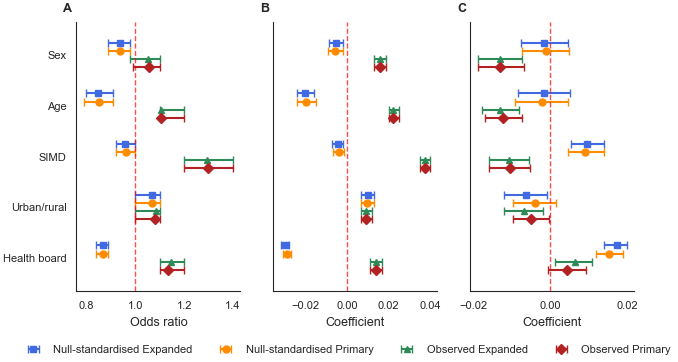

In [6]:
fig, axes = new_figure(
    nrows=1,
    ncols=3,
    width="double",
    height_in=3.5,
    sharey=True,
    )

plot_mixing_forest(
    axes[0],
    mixing_logistic,
    plot_scale=["null_standardised", "observed"],
    term_type="mixing_entropy",
)

plot_mixing_forest(
    axes[1],
    mixing_linear,
    outcome="burst_score",
    plot_scale=["null_standardised", "observed"],
    term_type="mixing_entropy",
)

plot_mixing_forest(
    axes[2],
    mixing_linear,
    outcome="burden_score",
    plot_scale=["null_standardised", "observed"],
    term_type="mixing_entropy",
)

add_panel_labels(axes, y=1.07)

handles, labels = axes[0].get_legend_handles_labels()

for ax in axes:
    leg = ax.get_legend()
    if leg:
        leg.remove()

fig.legend(
    handles=handles,
    labels=labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=4,
    frameon=False,
);

In [7]:
outliers = ["Orkney", "Western Isles"]

composition_logistic_outliers = composition_logistic[composition_logistic["plot_label"].isin(outliers)]
composition_linear_outliers = composition_linear[composition_linear["plot_label"].isin(outliers)]

print("Composition Logistic Outliers:\n",
    composition_logistic_outliers[
        [
            "model_set",
            "plot_variable",
            "plot_label",
            "plot_estimate",
            "plot_hdi95_low",
            "plot_hdi95_high",
        ]
    ]
    .sort_values(by=["plot_label"])
    .to_string(index=False),
    "\n"
)
print("Composition Linear Outliers:\n",
    composition_linear_outliers[
        [
            "outcome",
            "model_set",
            "plot_variable",
            "plot_label",
            "plot_estimate",
            "plot_hdi95_low",
            "plot_hdi95_high",
        ]
    ]
    .sort_values(by=["plot_label"])
    .to_string(index=False)
)

Composition Logistic Outliers:
 model_set   plot_variable    plot_label  plot_estimate  plot_hdi95_low  plot_hdi95_high
  primary dz_health_board        Orkney          4.129            3.30              5.1
 expanded dz_health_board        Orkney          3.839            3.00              4.8
  primary dz_health_board Western Isles          1.653            1.10              2.3
 expanded dz_health_board Western Isles          1.480            0.99              2.1 

Composition Linear Outliers:
      outcome model_set   plot_variable    plot_label  plot_estimate  plot_hdi95_low  plot_hdi95_high
 burst_score   primary dz_health_board        Orkney         0.0668         0.04300            0.090
 burst_score  expanded dz_health_board        Orkney         0.0507         0.02800            0.074
burden_score   primary dz_health_board        Orkney        -0.1959        -0.24000           -0.160
burden_score  expanded dz_health_board        Orkney        -0.2189        -0.26000         

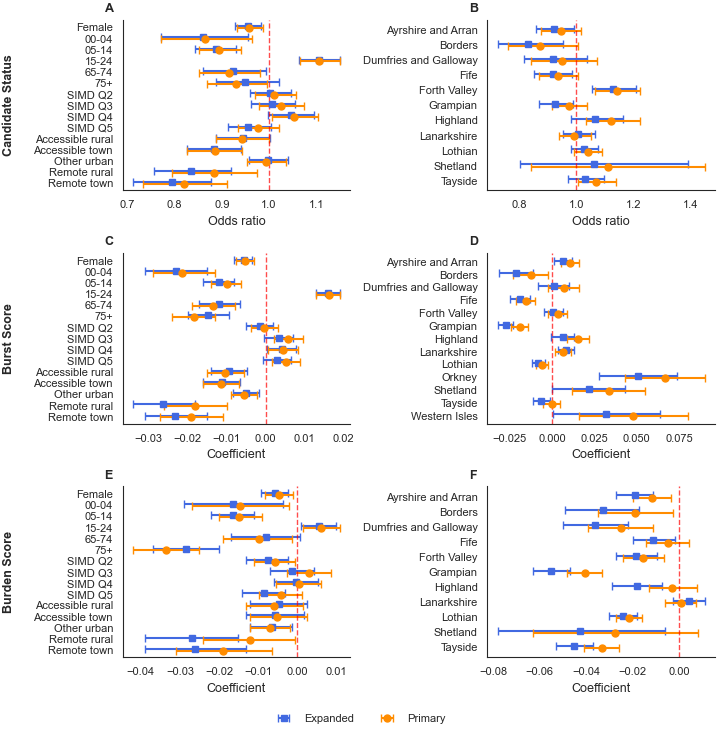

In [8]:
fig, axes = new_figure(
    nrows=3,
    ncols=2,
    width="double",
    height_in=7,
    constrained_layout=True
    )

plot_composition_forest(
    axes[0,0],
    composition_logistic,
    panel=["demographic", "socioeconomic"],
    term_type="categorical_contrast",
    label_col="plot_label",
)

plot_composition_forest(
    axes[0,1],
    composition_logistic,
    panel="geographic",
    term_type="categorical_contrast",
    label_col="plot_label",
    exclude=outliers
)

plot_composition_forest(
    axes[1,0],
    composition_linear,
    outcome="burst_score",
    panel=["demographic", "socioeconomic"],
    term_type="categorical_contrast",
    label_col="plot_label",
)

plot_composition_forest(
    axes[1,1],
    composition_linear,
    outcome="burst_score",
    panel="geographic",
    term_type="categorical_contrast",
    label_col="plot_label",
)

plot_composition_forest(
    axes[2,0],
    composition_linear,
    outcome="burden_score",
    panel=["demographic", "socioeconomic"],
    term_type="categorical_contrast",
    label_col="plot_label",
)

plot_composition_forest(
    axes[2,1],
    composition_linear,
    outcome="burden_score",
    panel="geographic",
    term_type="categorical_contrast",
    label_col="plot_label",
    exclude=outliers
)

add_panel_labels(axes.flatten(), y=1.1)

handles, labels = axes[0,0].get_legend_handles_labels()

for ax in axes.flatten():
    leg = ax.get_legend()
    if leg:
        leg.remove()


axes[0,0].annotate(
    "Candidate Status",
    xy=(-0.5, 0.5),
    xycoords="axes fraction",
    ha="center",
    va="center",
    rotation=90,
    fontweight="bold",
)

axes[1,0].annotate(
    "Burst Score",
    xy=(-0.5, 0.5),
    xycoords="axes fraction",
    ha="center",
    va="center",
    rotation=90,
    fontweight="bold"

)

axes[2,0].annotate(
    "Burden Score",
    xy=(-0.5, 0.5),
    xycoords="axes fraction",
    ha="center",
    va="center",
    rotation=90,
    fontweight="bold"
)


fig.legend(
    handles=handles,
    labels=labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=2,
    frameon=False,
);

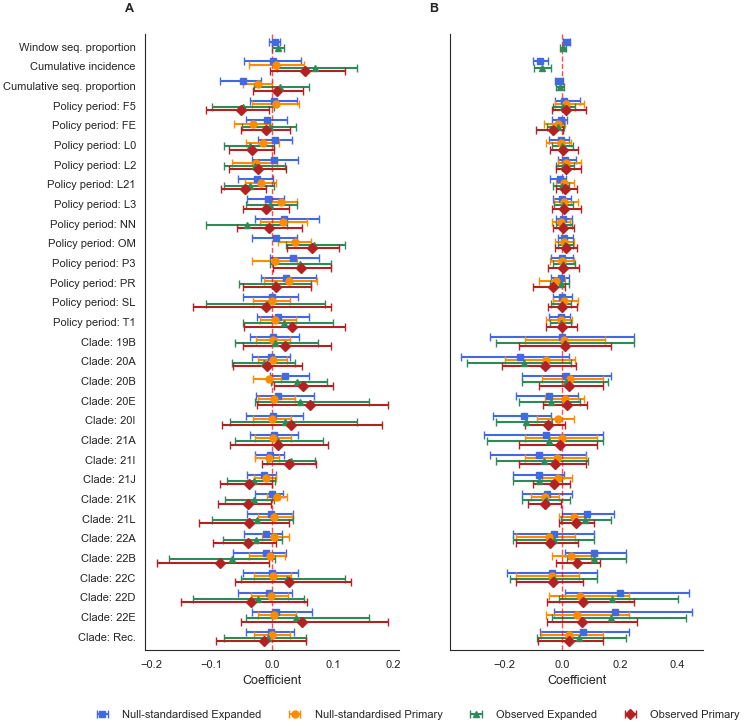

In [9]:
fig, axes = new_figure(
    nrows=1,
    ncols=2,
    width="double",
    height_in=8,
    sharey=True,
    )

plot_mixing_forest(
    axes[0],
    mixing_linear,
    outcome="burst_score",
    plot_scale=["null_standardised", "observed"],
    term_type=["continuous_adjuster", "random_intercept"],
)

plot_mixing_forest(
    axes[1],
    mixing_linear,
    outcome="burden_score",
    plot_scale=["null_standardised", "observed"],
    term_type=["continuous_adjuster", "random_intercept"],
)

add_panel_labels(axes, y=1.05)

handles, labels = axes[0].get_legend_handles_labels()

for ax in axes:
    leg = ax.get_legend()
    if leg:
        leg.remove()

fig.legend(
    handles=handles,
    labels=labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=4,
    frameon=False,
);

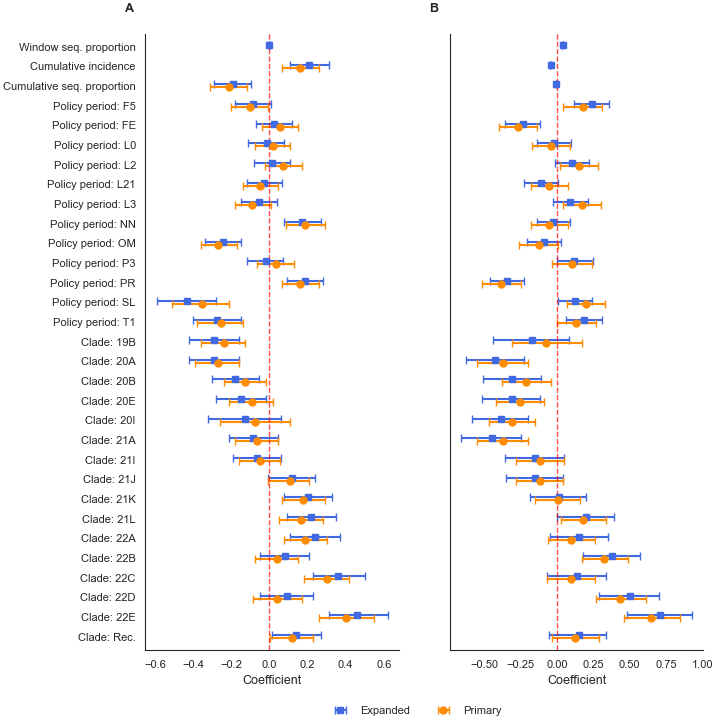

In [10]:
fig, axes = new_figure(
    nrows=1,
    ncols=2,
    width="double",
    height_in=8,
    sharey=True,
    )

plot_composition_forest(
    axes[0],
    composition_linear,
    outcome="burst_score",
    term_type=["continuous_adjuster", "random_intercept"],
    exclude=outliers
)

plot_composition_forest(
    axes[1],
    composition_linear,
    outcome="burden_score",
    term_type=["continuous_adjuster", "random_intercept"],
    exclude=outliers
)

add_panel_labels(axes, y=1.05)

handles, labels = axes[0].get_legend_handles_labels()

for ax in axes:
    leg = ax.get_legend()
    if leg:
        leg.remove()

fig.legend(
    handles=handles,
    labels=labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.015),
    ncol=2,
    frameon=False,
);

In [11]:
int(eval("1.0"))

1